
  Data yang diberikan:
  x        f(x)    
  ----------------
  2        3       
  4        5       
  5        1       
  6        6       
  7        9       

  PERHITUNGAN BASIS LAGRANGE Li(x)
  Evaluasi pada x = 3

  L0(x) = (x - 4) / (2 - 4) * (x - 5) / (2 - 5) * (x - 6) / (2 - 6) * (x - 7) / (2 - 7)
        = 0.200000
  y0 * L0(x) = 3 * 0.200000 = 0.600000

  L1(x) = (x - 2) / (4 - 2) * (x - 5) / (4 - 5) * (x - 6) / (4 - 6) * (x - 7) / (4 - 7)
        = 2.000000
  y1 * L1(x) = 5 * 2.000000 = 10.000000

  L2(x) = (x - 2) / (5 - 2) * (x - 4) / (5 - 4) * (x - 6) / (5 - 6) * (x - 7) / (5 - 7)
        = -2.000000
  y2 * L2(x) = 1 * -2.000000 = -2.000000

  L3(x) = (x - 2) / (6 - 2) * (x - 4) / (6 - 4) * (x - 5) / (6 - 5) * (x - 7) / (6 - 7)
        = 1.000000
  y3 * L3(x) = 6 * 1.000000 = 6.000000

  L4(x) = (x - 2) / (7 - 2) * (x - 4) / (7 - 4) * (x - 5) / (7 - 5) * (x - 6) / (7 - 6)
        = -0.200000
  y4 * L4(x) = 9 * -0.200000 = -1.800000

  TABEL RINGKASAN PADA x = 3
  i    

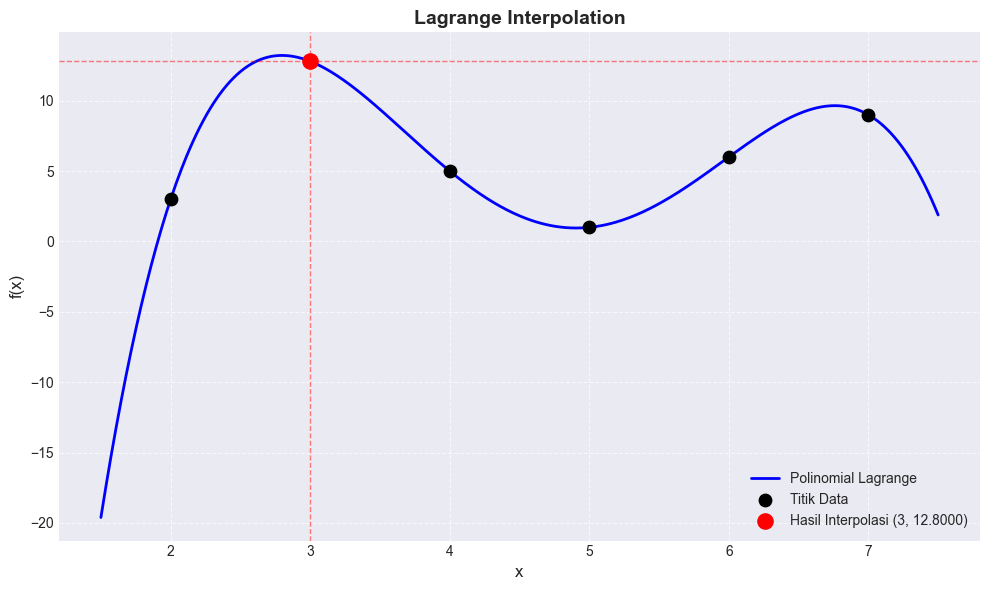

In [1]:
"""
================================================
  INTERPOLASI POLINOMIAL

  Metode: Lagrange Interpolation

  Konsep:
    Diberikan n+1 titik data (x0,y0), (x1,y1), ..., (xn,yn),
    cari polinomial derajat <= n yang melewati semua titik:

    fn(x) = sum( yi * Li(x) )   untuk i = 0, 1, ..., n

    di mana basis Lagrange Li(x) didefinisikan sebagai:

    Li(x) = prod( (x - xj) / (xi - xj) )  untuk j != i

    Setiap Li(xi) = 1  dan  Li(xj) = 0 untuk j != i
    sehingga polinomial melewati semua titik data.
================================================
"""

import matplotlib.pyplot as plt
import numpy as np


# ── HITUNG BASIS LAGRANGE Li(x) ───────────────────────────────────────────
def basis_lagrange(X, i, x):
    """
    Menghitung nilai basis Lagrange ke-i pada titik x.

    Li(x) = prod( (x - xj) / (xi - xj) )  untuk semua j != i

    Parameters
    ----------
    X : list[float]  -- vektor titik x data
    i : int          -- indeks basis yang dihitung
    x : float        -- titik evaluasi

    Returns
    -------
    hasil : float    -- nilai Li(x)
    """
    n = len(X)
    hasil = 1.0
    for j in range(n):
        if j != i:
            hasil *= (x - X[j]) / (X[i] - X[j])
    return hasil


# ── EVALUASI POLINOMIAL LAGRANGE ──────────────────────────────────────────
def lagrange_interpolate(X, Y, x_query, verbose=False):
    """
    Mengevaluasi polinomial Lagrange pada titik x_query.

    fn(x) = y0*L0(x) + y1*L1(x) + ... + yn*Ln(x)

    Parameters
    ----------
    X       : list[float]  -- vektor titik x data
    Y       : list[float]  -- vektor titik y data
    x_query : float        -- titik yang ingin diinterpolasi
    verbose : bool         -- cetak detail perhitungan tiap basis

    Returns
    -------
    hasil : float -- nilai interpolasi fn(x_query)
    """
    n = len(X)
    hasil = 0.0

    if verbose:
        print(f"  Evaluasi pada x = {x_query}")
        print()

    for i in range(n):
        Li = basis_lagrange(X, i, x_query)
        kontribusi = Y[i] * Li
        hasil += kontribusi

        if verbose:
            print(f"  L{i}(x) = ", end="")
            # cetak rumus basis secara simbolik
            faktor_list = []
            for j in range(n):
                if j != i:
                    faktor_list.append(f"(x - {X[j]}) / ({X[i]} - {X[j]})")
            print(" * ".join(faktor_list))
            print(f"        = {Li:.6f}")
            print(f"  y{i} * L{i}(x) = {Y[i]} * {Li:.6f} = {kontribusi:.6f}")
            print()

    return hasil


# ── CETAK TABEL BASIS LAGRANGE ────────────────────────────────────────────
def cetak_tabel_basis(X, Y, x_query):
    n = len(X)
    print(f"  {'i':<5} {'xi':<10} {'yi':<10} {'Li(x)':<14} {'yi * Li(x)':<14}")
    print("  " + "-" * 55)

    total = 0.0
    for i in range(n):
        Li = basis_lagrange(X, i, x_query)
        kontribusi = Y[i] * Li
        total += kontribusi
        print(f"  {i:<5} {X[i]:<10.4f} {Y[i]:<10.4f} {Li:<14.6f} {kontribusi:<14.6f}")

    print("  " + "-" * 55)
    print(f"  {'':5} {'':10} {'Jumlah':>10}  {'':14} {total:<14.6f}")


# ── VISUALISASI ───────────────────────────────────────────────────────────
def visualisasi(X, Y, x_query, y_query):
    x_plot = np.linspace(min(X) - 0.5, max(X) + 0.5, 500)
    y_plot = [lagrange_interpolate(X, Y, xi) for xi in x_plot]

    plt.style.use('seaborn-v0_8-darkgrid')
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(x_plot, y_plot, color='blue', linewidth=2, label="Polinomial Lagrange")
    ax.scatter(X, Y, color='black', s=80, zorder=5, label="Titik Data")
    ax.scatter(x_query, y_query, color='red', s=120, zorder=6,
               label=f"Hasil Interpolasi ({x_query}, {y_query:.4f})")
    ax.axvline(x_query, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.axhline(y_query, color='red', linewidth=1, linestyle='--', alpha=0.5)

    ax.set_title("Lagrange Interpolation", fontsize=14, fontweight='bold')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


# ── CONTOH SOAL ───────────────────────────────────────────────────────────
if __name__ == "__main__":

    # Data dari slide CISE301 Topic 5:
    #
    # | x | f(x) |
    # | 2 |  3   |
    # | 4 |  5   |
    # | 5 |  1   |
    # | 6 |  6   |
    # | 7 |  9   |
    #
    # Cari polinomial interpolasi, lalu estimasi f(3).
    # Catatan: Newton & Lagrange harus menghasilkan jawaban yang sama.

    X = [2, 4, 5, 6, 7]
    Y = [3, 5, 1, 6, 9]
    x_query = 3

    print("\n  Data yang diberikan:")
    print(f"  {'x':<8} {'f(x)':<8}")
    print("  " + "-" * 16)
    for xi, yi in zip(X, Y):
        print(f"  {xi:<8} {yi:<8}")

    # ── Detail perhitungan basis Lagrange
    print("\n" + "="*60)
    print("  PERHITUNGAN BASIS LAGRANGE Li(x)")
    print("="*60)
    lagrange_interpolate(X, Y, x_query, verbose=True)

    # ── Tabel ringkasan
    print("="*60)
    print(f"  TABEL RINGKASAN PADA x = {x_query}")
    print("="*60)
    cetak_tabel_basis(X, Y, x_query)

    # ── Hasil interpolasi
    print("\n" + "="*60)
    print(f"  HASIL INTERPOLASI PADA x = {x_query}")
    print("="*60)
    y_query = lagrange_interpolate(X, Y, x_query)
    print(f"  f({x_query}) ≈ {y_query:.6f}")

    # ── Visualisasi
    visualisasi(X, Y, x_query, y_query)